### Transformer Decoder를 활용한 문장 의도 분류 v2

1) 다음 단어를 예측하도록 학습 (v1 대비 추가)
2) 출력의 마지막 토큰 하나만 뽑아 의도 분류용 FC Layer를 통과 시킴

### 파일을 Google Drive에 저장하고 사용

개인 Drive 폴더 구조에 맞게 변경하여 사용 필요

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks/Transformer/TF04')

print(f'현재 작업 폴더: {os.getcwd()}')

Mounted at /content/drive
현재 작업 폴더: /content/drive/MyDrive/Colab Notebooks/Transformer/TF04


### 문장 토큰 수 확인

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 160.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 76.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/371k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

[문장 0] 지금 배달되나요?
  → 토큰: ['▁지금', '▁배', '달', '되', '나', '요', '?']
[문장 1] 짬뽕류는 어떤 게 있나요? 잘 나가는 짬뽕 있나요?
  → 토큰: ['▁', '짬', '뽕', '류', '는', '▁어떤', '▁게', '▁있', '나', '요', '?', '▁잘', '▁나가', '는', '▁', '짬', '뽕', '▁있', '나', '요', '?']
[문장 2] 전복 들어가는 거는 특해물 짬뽕 시켜야 돼요?
  → 토큰: ['▁전', '복', '▁들어가', '는', '▁거', '는', '▁특', '해', '물', '▁', '짬', '뽕', '▁', '시켜', '야', '▁돼', '요', '?']
[문장 3] 전복 들어가고 여러 가지 또 딴 것도 들어가죠?
  → 토큰: ['▁전', '복', '▁들어가', '고', '▁여러', '▁가지', '▁또', '▁', '딴', '▁것도', '▁들어가', '죠', '?']
[문장 4] 마차이 짬뽕밥은 돼지고기 들어가나요?
  → 토큰: ['▁마', '차', '이', '▁', '짬', '뽕', '밥', '은', '▁돼', '지고', '기', '▁들어가', '나', '요', '?']
[문장 5] 여기 #주소#인데 배달되나요?
  → 토큰: ['▁여기', '▁', '#', '주', '소', '#', '인데', '▁배', '달', '되', '나', '요', '?']
[문장 6] 중국집 명성루죠? 배달 지금 가능한가요?
  → 토큰: ['▁중국', '집', '▁명', '성', '루', '죠', '?', '▁배', '달', '▁지금', '▁가능한', '가', '요', '?']
[문장 7] 주로 어떤 게 잘 나가요?
  → 토큰: ['▁주로', '▁어떤', '▁게', '▁잘', '▁나가', '요', '?']
[문장 8] 4인이 먹을 수 있을까요?
  → 토큰: ['▁4', '인', '이', '▁먹', '을', '▁수', '▁있을까', '요', '?']
[문장 9] 중자는 얼마에요?
  → 토

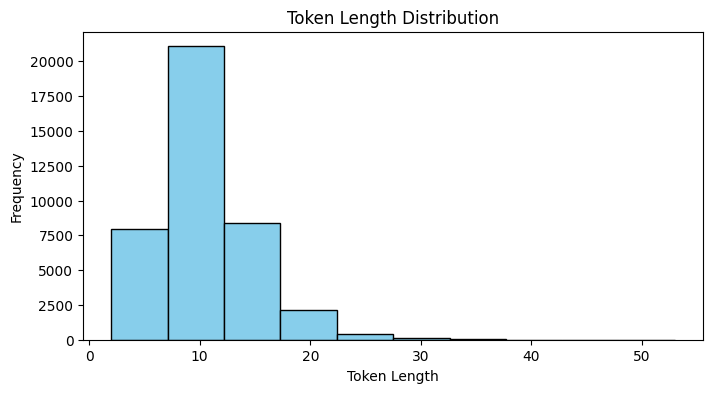

In [ ]:
!pip install transformers==4.57.6

from transformers import AutoTokenizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tokenizer = AutoTokenizer.from_pretrained('skt/kobert-base-v1', use_fast=False)

df = pd.read_csv('../data/dialog_data.csv')
cafe_df = df[df['SPEAKER'] == '고객'].copy()

cafe_df['TOKENS'] = cafe_df['SENTENCE'].apply(lambda x: tokenizer.tokenize(x))
cafe_df['TOKEN_LENGTH'] = cafe_df['TOKENS'].apply(len)
for i, (sent, tokens) in cafe_df[['SENTENCE', 'TOKENS']].head(10).iterrows():
    print(f'[문장 {i}] {sent}')
    print(f'  → 토큰: {tokens}')

token_lengths = cafe_df['TOKEN_LENGTH']
print(f'총 문장 수: {len(token_lengths)}')
print(f'최대 토큰 길이: {token_lengths.max()}')
print(f'평균 토큰 길이: {token_lengths.mean():.2f}')
print(f'95th 백분위수(상위 10% 컷): {np.percentile(token_lengths, 90)}')
print(f'95th 백분위수(상위 5% 컷): {np.percentile(token_lengths, 95)}')
print(f'99th 백분위수(상위 1% 컷): {np.percentile(token_lengths, 99)}')

plt.figure(figsize=(8,4))
plt.hist(token_lengths, color='skyblue', edgecolor='black')
plt.title('Token Length Distribution')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
!pip install prettytable
!pip install koeda

import pandas as pd
import torch
import torch.nn as nn
from koeda import RandomSwap, RandomDeletion
from prettytable import PrettyTable
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from transformers import AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 159.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 64.8 MB/s eta 0:00:00
  Attempting uninstall: tweepy
    Found existing installation: tweepy 4.16.0
    Uninstalling tweepy-4.16.0:
      Successfully uninstalled tweepy-4.16.0
True


In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_accuracy = 0.0
        self.counter = 0
        self.best_model = None

    def __call__(self, accuracy, model):
        if accuracy > self.best_accuracy + self.min_delta:
            self.best_accuracy = accuracy
            self.counter = 0
            self.best_model = model.state_dict()
        else:
            self.counter += 1
        return self.counter >= self.patience

In [ ]:
class IntentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):
        self.sentences = df['SENTENCE'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):  # Dataset 크기 (샘플 개수) 반환
        return len(self.sentences)

    def __getitem__(self, idx):
        prompt = '\n 문의 의도는: '
        sentence = self.sentences[idx] + prompt

        encoding = self.tokenizer(
            sentence,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
class MaskedTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, pad_id, num_classes, d_model=256, nhead=4, num_layers=3, dim_feedforward=512,
                 max_len=64, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout,
                                                   batch_first=True, norm_first=True)

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.layer_norm = nn.LayerNorm(d_model)

        # 다음 단어 예측을 위한 Language Modeling Head
        self.lm_head = nn.Linear(d_model, vocab_size)
        # 최종 의도 분류를 위한 Classifier Head
        self.classifier = nn.Linear(d_model, num_classes)

    def _generate_causal_mask(self, seq_len, device):
        # 상삼각행렬을 1로 채우고 bool 타입으로 변환 (True: 마스킹 됨, False: 마스킹 안 됨)
        mask = torch.triu(torch.ones((seq_len, seq_len), dtype=torch.bool, device=device), diagonal=1)
        return mask

    def forward(self, input_ids, attention_mask=None):
        batch_size, seq_len = input_ids.size()
        pos = torch.arange(0, seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)

        x = self.embedding(input_ids) + self.pos_embedding(pos)  # (Batch, Sequence, d_model)

        # Causal Mask 생성
        causal_mask = self._generate_causal_mask(seq_len, device=input_ids.device)

        # TransformerEncoder의 mask 처리 (True가 mask되어 제외됨, False는 참조)
        x = self.encoder(x, mask=causal_mask, src_key_padding_mask=(attention_mask == 0))

        # 전체 시퀀스에 대한 다음 단어 예측(LM) Logits 생성
        lm_logits = self.lm_head(x)  # (Batch, Sequence, vocab_size)

        # 가변적인 마지막 유효 토큰(CLS 위치) 추출
        # attention_mask에서 값이 1인 개수를 세어 1을 빼면 마지막 유효 토큰의 인덱스가 됨
        last_token_indices = attention_mask.sum(dim=1) - 1
        batch_indices = torch.arange(batch_size, device=input_ids.device)
        last_token_hidden = x[batch_indices, last_token_indices]

        last_token_hidden = self.layer_norm(last_token_hidden)
        cls_logits = self.classifier(last_token_hidden)  # (Batch, num_classes)

        return lm_logits, cls_logits

    def replace_classifier(self, new_num_classes):
        # Fine-tuning을 위해 Classifier Head 교체 할때 사용
        print(f'\n Replacing classifier head: {self.classifier.out_features} → {new_num_classes} classes')
        self.classifier = nn.Linear(self.d_model, new_num_classes)

In [ ]:
def augment_dataframe(df, num_aug=1):
    swap = RandomSwap(morpheme_analyzer='Okt')
    delete = RandomDeletion(morpheme_analyzer='Okt')
    new_data = []
    for _, row in df.iterrows():
        sentence = row['SENTENCE']
        label = row['label']
        new_data.append({'SENTENCE': sentence, 'label': label})
        for _ in range(num_aug):
            new_data.append({'SENTENCE': swap(sentence, 0.0), 'label': label})
            new_data.append({'SENTENCE': delete(sentence, 0.2), 'label': label})
    return pd.DataFrame(new_data)

### 학습 Data Set 신규 생성

In [ ]:
def prepare_datasets_from_scratch(tokenizer, batch_size=64, max_length=64, num_aug=1):
    print('\n Loading Data...')
    df = pd.read_csv('../data/dialog_data.csv')
    df = df[df['SPEAKER'] == '고객'].copy()
    df = df[['DOMAIN', 'SENTENCE', 'MAIN_GROUPED']].copy()
    print(df)

    print('\n Deleting Small Data...')
    label_counts = df['MAIN_GROUPED'].value_counts()
    rare_classes = label_counts[label_counts < 2].index
    df = df[~df['MAIN_GROUPED'].isin(rare_classes)].copy()
    print(df)

    print('\n Loading Augmented Data...')
    augmented_df = pd.read_csv('../data/dialog_data_augmented2.csv')
    df = pd.concat([df, augmented_df], ignore_index=True)
    print(df)

    print('\n Dividing Target Domain...')
    target_df = df[df['DOMAIN'] == '카페'].copy()
    print(target_df)

    print('\n Dividing Target Train and Validation ...')
    target_train, target_val = train_test_split(
        target_df, test_size=0.2, random_state=42, stratify=target_df['MAIN_GROUPED']
    )
    print(target_train)
    print(target_val)

    print('\n Adding labels ...')
    label_encoder = LabelEncoder()
    label_encoder.fit(target_df['MAIN_GROUPED'])
    target_train['label'] = label_encoder.transform(target_train['MAIN_GROUPED'])
    target_val['label'] = label_encoder.transform(target_val['MAIN_GROUPED'])
    print(target_train)
    print(target_val)

    print('\n Augmenting Train Data...')
    target_train = augment_dataframe(target_train, num_aug)
    print(target_train)

    print('\n Deleting Useless Data...')
    target_train = target_train[~(target_train['SENTENCE'] == '')].copy()
    print(target_train)

    target_train.to_csv('../data/intent_classification_fine_tuning_train.csv', index=False)
    target_train.to_csv('../data/intent_classification_fine_tuning_train.csv.zip', index=False, compression='zip')
    target_val.to_csv('../data/intent_classification_fine_tuning_val.csv', index=False)
    target_val.to_csv('../data/intent_classification_fine_tuning_val.csv.zip', index=False, compression='zip')

    print('\n Preparing DataLoader...')
    train_dataset = IntentDataset(target_train, tokenizer, max_length)
    val_dataset = IntentDataset(target_val, tokenizer, max_length)
    data_loaders = {
        'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True),
        'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=1, pin_memory=True),
        'class_weights': None,
        'num_classes': len(label_encoder.classes_)
    }

    print('\n Done.')
    return data_loaders

### 저장된 파일을 재활용

In [ ]:
def prepare_datasets(tokenizer, batch_size=64, max_length=64):
    target_train = pd.read_csv('../data/intent_classification_fine_tuning_train.csv.zip', compression='zip', low_memory=False)
    target_val = pd.read_csv('../data/intent_classification_fine_tuning_val.csv.zip', compression='zip', low_memory=False)

    print('\n Preparing DataLoader...')
    train_dataset = IntentDataset(target_train, tokenizer, max_length)
    val_dataset = IntentDataset(target_val, tokenizer, max_length)
    data_loaders = {
        'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True),
        'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=1, pin_memory=True),
        'class_weights': None,
        'num_classes': target_train['label'].max() + 1
    }

    return data_loaders

In [ ]:
def analyze_model_parameters(model):
    table = PrettyTable(['Layer Name', 'Parameter Count', 'Shape'])
    total_params = 0

    for name, parameter in model.named_parameters():
        if parameter.requires_grad:
            params = parameter.numel()
            table.add_row([name, f'{params:,}', str(list(parameter.shape))])
            total_params += params

    print(table)
    print(f'\n 전체 훈련 가능한 파라미터: {total_params:,}')

In [ ]:
def train_epoch(model, loader, criterion_cls, criterion_lm, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        lm_logits, cls_logits = model(input_ids, mask)

        # 1. 의도 분류 Loss 계산
        # cls_logits : (batch_size, num_classes), labels : (batch_size)
        loss_cls = criterion_cls(cls_logits, labels)

        # 2. 다음 단어 예측(LM) Loss 계산
        # 정답(Target)은 입력 시퀀스를 한 칸(1 step) 미래로 당긴 값
        shift_logits = lm_logits[..., :-1, :].contiguous()  # 마지막을 제외한 lm_logits (batch_size, sequence, vocab_size)
        shift_labels = input_ids[..., 1:].contiguous()  # 0번째를 제외한 input_ids (batch_size, sequence)
        loss_lm = criterion_lm(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))

        # 3. Total Loss 계산 (단순 합산 또는 가중치 부여 가능. 예: 0.7 * loss_cls + 0.3 * loss_lm)
        loss = (0.8 * loss_cls) + (0.2 * loss_lm)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
        preds = cls_logits.argmax(dim=1)  # preds : (batch_size), 정확도는 여전히 의도 분류 기준으로 측정
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

In [ ]:
def eval_epoch(model, loader, criterion_cls, criterion_lm, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():

        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            lm_logits, cls_logits = model(input_ids, mask)
            loss_cls = criterion_cls(cls_logits, labels)

            shift_logits = lm_logits[..., :-1, :].contiguous()
            shift_labels = input_ids[..., 1:].contiguous()
            loss_lm = criterion_lm(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))

            loss = (0.8 * loss_cls) + (0.2 * loss_lm)

            total_loss += loss.item() * input_ids.size(0)
            predicted = cls_logits.argmax(dim=1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [ ]:
def train(device, tokenizer, data_loaders, params):
    model = MaskedTransformerClassifier(
        vocab_size=len(tokenizer), pad_id=tokenizer.pad_token_id, num_classes=data_loaders['num_classes'],
        d_model=params['d_model'], nhead=params['nhead'], num_layers=params['num_layers'],
        dim_feedforward=params['dim_feedforward'], max_len=params['max_length'], dropout=params['dropout']
    ).to(device)

    analyze_model_parameters(model)

    # 두 가지 목적을 위한 Loss 선언
    criterion_cls = nn.CrossEntropyLoss(weight=data_loaders['class_weights'], label_smoothing=params['label_smoothing'])
    # 패딩 토큰은 다음 단어 예측(Loss 계산)에서 무시하도록 설정
    criterion_lm = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

    optimizer = torch.optim.AdamW(model.parameters(), lr=params['learning_rate'], weight_decay=params['weight_decay'])
    early_stopping = EarlyStopping(params['epochs'], 0)

    writer = SummaryWriter(f'../tensorboard/intent-classification-tf-decoder-v2')

    for epoch in tqdm(range(params['epochs'])):
        train_loss, train_acc = train_epoch(model, data_loaders['train'], criterion_cls, criterion_lm, optimizer, device)
        val_loss, val_acc = eval_epoch(model, data_loaders['val'], criterion_cls, criterion_lm, device)

        writer.add_scalars('loss', {'train': train_loss, 'validation': val_loss}, epoch + 1)
        writer.add_scalars('accuracy', {'train': train_acc, 'validation': val_acc}, epoch + 1)
        print(f'Epoch {epoch + 1}: train_loss={train_loss:.4f} acc={train_acc:.4f} '
              f'| val_loss={val_loss:.4f} acc={val_acc:.4f}')

        if early_stopping(val_acc, model):
            print('Early stopping triggered.')
            break

    print(f'Training finished. Best Accuracy: {early_stopping.best_accuracy:.4f}')
    writer.close()

    torch.save(early_stopping.best_model, '../model/tf-decoder-v2.pt')

In [ ]:
# 실험 파라미터
params = {
    'num_layers': 2,
    'nhead': 16,
    'd_model': 1024,
    'dim_feedforward': 4096,
    'learning_rate': 1e-5,
    'weight_decay': 1e-3,
    'eta_min': 1e-6,
    'label_smoothing': 0.3,
    'dropout': 0.4,
    'batch_size': 64,
    'num_aug': 4,
    'epochs': 100,
    'max_length': 64
}

tokenizer = AutoTokenizer.from_pretrained('skt/kobert-base-v1', use_fast=False)
tokenizer.padding_side = 'right'  # 패딩이 뒤(오른쪽)에 오도록 설정

# 데이터 준비
# data_loaders = prepare_datasets_from_scratch(
#     tokenizer, params['batch_size'], params['max_length'], params['num_aug']
# )
data_loaders = prepare_datasets(tokenizer, params['batch_size'], params['max_length'])

train(device, tokenizer, data_loaders, params)


 Preparing DataLoader...


/tmp/ipykernel_3834/2105904778.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)


+--------------------------------------------+-----------------+--------------+
|                 Layer Name                 | Parameter Count |    Shape     |
+--------------------------------------------+-----------------+--------------+
|              embedding.weight              |    8,194,048    | [8002, 1024] |
|            pos_embedding.weight            |      65,536     |  [64, 1024]  |
| encoder.layers.0.self_attn.in_proj_weight  |    3,145,728    | [3072, 1024] |
|  encoder.layers.0.self_attn.in_proj_bias   |      3,072      |    [3072]    |
| encoder.layers.0.self_attn.out_proj.weight |    1,048,576    | [1024, 1024] |
|  encoder.layers.0.self_attn.out_proj.bias  |      1,024      |    [1024]    |
|      encoder.layers.0.linear1.weight       |    4,194,304    | [4096, 1024] |
|       encoder.layers.0.linear1.bias        |      4,096      |    [4096]    |
|      encoder.layers.0.linear2.weight       |    4,194,304    | [1024, 4096] |
|       encoder.layers.0.linear2.bias   

  1%|          | 1/100 [00:28<47:27, 28.76s/it]

Epoch 1: train_loss=4.1060 acc=0.1838 | val_loss=3.1734 acc=0.4970


...

Epoch 98: train_loss=1.9248 acc=0.9788 | val_loss=2.3542 acc=0.8147


 99%|█████████▉| 99/100 [45:49<00:27, 27.77s/it]

Epoch 99: train_loss=1.9234 acc=0.9789 | val_loss=2.3506 acc=0.8168


100%|██████████| 100/100 [46:17<00:00, 27.77s/it]

Epoch 100: train_loss=1.9223 acc=0.9790 | val_loss=2.3509 acc=0.8200
Training finished. Best Accuracy: 0.8256


In [ ]:
# TensorBoard 결과 출력
%load_ext tensorboard
%tensorboard --logdir=../tensorboard/

In [ ]:
from google.colab import runtime
import time

time.sleep(30)
runtime.unassign()